# C-MAPSS RUL Modeling

## Load Data

In [1]:
from pathlib import Path
import math

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

In [2]:
DATA_DIR = Path('..') / 'data'
DATASET_ID = 'FD003'
CAP = 125 

BASE_COLUMNS = [
    'unit_number',
    'time_cycles',
    'op_setting_1',
    'op_setting_2',
    'op_setting_3',
]



def load_training_data(dataset_id=DATASET_ID):
    path = f'../data/train_{dataset_id}.txt'
    dataframe = pd.read_csv(path, sep=r'\s+', header=None)
    sensor_count = len(dataframe.columns) - len(BASE_COLUMNS)
    sensor_columns = [
        f'sensor_measure_{i}' for i in range(1, sensor_count + 1)
    ]
    dataframe.columns = BASE_COLUMNS + sensor_columns
    return dataframe


def load_test_data(dataset_id=DATASET_ID):
    path = f'../data/test_{dataset_id}.txt'
    dataframe = pd.read_csv(path, sep=r'\s+', header=None)
    sensor_count = len(dataframe.columns) - len(BASE_COLUMNS)
    sensor_columns = [
        f'sensor_measure_{i}' for i in range(1, sensor_count + 1)
    ]
    dataframe.columns = BASE_COLUMNS + sensor_columns
    return dataframe

def load_rul(dataset_id=DATASET_ID):
    path = f'../data/RUL_{dataset_id}.txt'
    rul = pd.read_csv(path, sep=r'\s+', header=None, names=['RUL'])
    rul.index = rul.index + 1 
    rul.index.name = 'unit_number'
    return rul['RUL']


In [3]:
def attach_training_rul(train_df, cap=CAP):
    """Attach remaining cycles to every training row."""
    result = train_df.copy()
    final_cycle = result.groupby('unit_number')['time_cycles'].transform('max')
    result['RUL'] = final_cycle - result['time_cycles']
    if cap is not None:
        result['RUL'] = result['RUL'].clip(upper=cap)
    return result


def attach_test_rul(test_df, rul_series, cap=CAP):
    """Attach official end-of-test RUL plus elapsed cycles to every row."""
    result = test_df.copy()
    unit_last_cycle = result.groupby('unit_number')['time_cycles'].transform('max')
    result['RUL'] = result['unit_number'].map(rul_series)
    if result['RUL'].isna().any():
        missing_units = result.loc[result['RUL'].isna(), 'unit_number'].unique()
        raise ValueError(f'Missing official RUL values for units: {missing_units.tolist()}')
    result['RUL'] = result['RUL'] + unit_last_cycle - result['time_cycles']
    if cap is not None:
        result['RUL'] = result['RUL'].clip(upper=cap)
    return result

In [4]:
def cmapss_score(y_true, y_pred):
    errors = np.asarray(y_pred) - np.asarray(y_true)
    penalties = np.where(
        errors < 0,
        np.exp(-errors / 13) - 1,
        np.exp(errors / 10) - 1,
    )
    return float(np.sum(penalties))


def regression_metrics(y_true, y_pred):
    return {
        'cmapss_score': cmapss_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'r2': r2_score(y_true, y_pred),
    }

In [5]:
train = load_training_data()
test = load_test_data()
test_RUL = load_rul()

In [6]:
train = attach_training_rul(train)
test = attach_test_rul(test, test_RUL)

In [7]:
feature_candidates = [c for c in train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]
constant_cols = [c for c in feature_candidates if train[c].std() < 1e-6]
feature_cols = [c for c in feature_candidates if c not in constant_cols]

print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Training on {len(feature_cols)} features')

Dropped 6 constant columns: ['op_setting_3', 'sensor_measure_1', 'sensor_measure_5', 'sensor_measure_16', 'sensor_measure_18', 'sensor_measure_19']
Training on 18 features


In [8]:
SEED = 42
SEQ_LEN = 30

def make_windows(frame, seq_len=SEQ_LEN, last_only=False):
    windows, targets, groups = [], [], []

    for unit_id, group in frame.groupby('unit_number', sort=True):
        group = group.sort_values('time_cycles')
        data = group[feature_cols].values
        target = group['RUL'].values

        # Padding logic for short sequences (critical for FD002-FD004 or real-world data)
        if len(group) < seq_len:
            pad_length = seq_len - len(group)
            padded_data = np.pad(data, ((pad_length, 0), (0, 0)), mode='edge')
            
            if last_only:
                windows.append(padded_data)
                targets.append(target[-1])
                groups.append(unit_id)
            else:
                windows.append(padded_data)
                targets.append(target[-1])
                groups.append(unit_id)
            continue

        starts = [len(group) - seq_len] if last_only else range(len(group) - seq_len + 1)
        for start in starts:
            windows.append(data[start:start + seq_len])
            targets.append(target[start + seq_len - 1])
            groups.append(unit_id)

    return np.asarray(windows, dtype=np.float32), np.asarray(targets, dtype=np.float32), np.asarray(groups)

## ML

### XGBoost

In [9]:
X = train[feature_cols]
y = train['RUL']
groups = train['unit_number']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(splitter.split(X, y, groups=groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

print(f'Train units: {groups.iloc[train_idx].nunique()}, Val units: {groups.iloc[val_idx].nunique()}')

Train units: 80, Val units: 20


In [10]:
xgb_params = {
    'n_estimators': 700,
    'max_depth': 5,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'eval_metric': 'rmse',
}

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

print(f'Best iteration: {xgb_model.best_iteration}')

Best iteration: 185


In [11]:
val_pred = xgb_model.predict(X_val)
val_metrics = regression_metrics(y_val, val_pred)
val_metrics

{'cmapss_score': 42767.614779554635,
 'mae': 10.545683860778809,
 'rmse': 15.623401285399073,
 'r2': 0.8546914458274841}

In [12]:
test_last_cycle = test.loc[test.groupby('unit_number')['time_cycles'].idxmax()]

X_test = test_last_cycle[feature_cols]
y_test = test_last_cycle['RUL']

test_pred = xgb_model.predict(X_test)
xgb_test_metrics = regression_metrics(y_test, test_pred)
xgb_test_metrics

{'cmapss_score': 2207.6757417195354,
 'mae': 15.093106269836426,
 'rmse': 20.79832768686734,
 'r2': 0.7180082201957703}

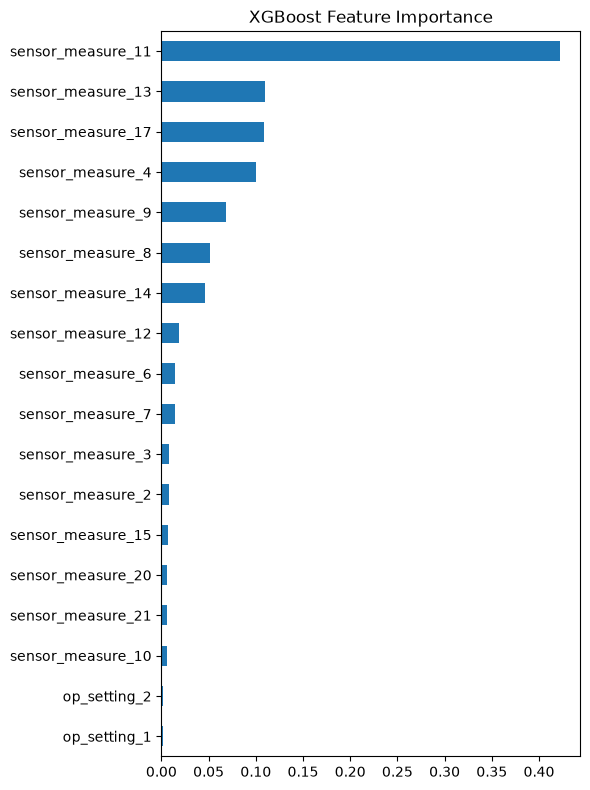

In [13]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 8))
importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

### Enhanced XGBoost

In [14]:
# Generate 3D sequences using the existing make_windows function
X_seq, y_seq, groups_seq = make_windows(train, seq_len=SEQ_LEN)

# Flatten sequences from (n_samples, 30, 17) to (n_samples, 510)
X_seq_flat = X_seq.reshape(X_seq.shape[0], -1)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(splitter.split(X_seq_flat, y_seq, groups=groups_seq))

X_train, X_val = X_seq_flat[train_idx], X_seq_flat[val_idx]
y_train, y_val = y_seq[train_idx], y_seq[val_idx]

print(f'Train units: {len(np.unique(groups_seq[train_idx]))}, Val units: {len(np.unique(groups_seq[val_idx]))}')

Train units: 80, Val units: 20


In [15]:
xgb_params = {
    'n_estimators': 700,
    'max_depth': 5,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'eval_metric': 'rmse',
}

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

print(f'Best iteration: {xgb_model.best_iteration}')

Best iteration: 698


In [16]:
# Process test set using the same windowing logic (last cycle only)
x_test_seq, y_test, test_groups = make_windows(test, seq_len=SEQ_LEN, last_only=True)

# Flatten to match the training shape
X_test_flat = x_test_seq.reshape(x_test_seq.shape[0], -1)

test_pred = xgb_model.predict(X_test_flat)
xgb_test_metrics_2 = regression_metrics(y_test, test_pred)
xgb_test_metrics_2

{'cmapss_score': 560.8809814453125,
 'mae': 10.806248664855957,
 'rmse': 14.680435364631295,
 'r2': 0.8595060706138611}

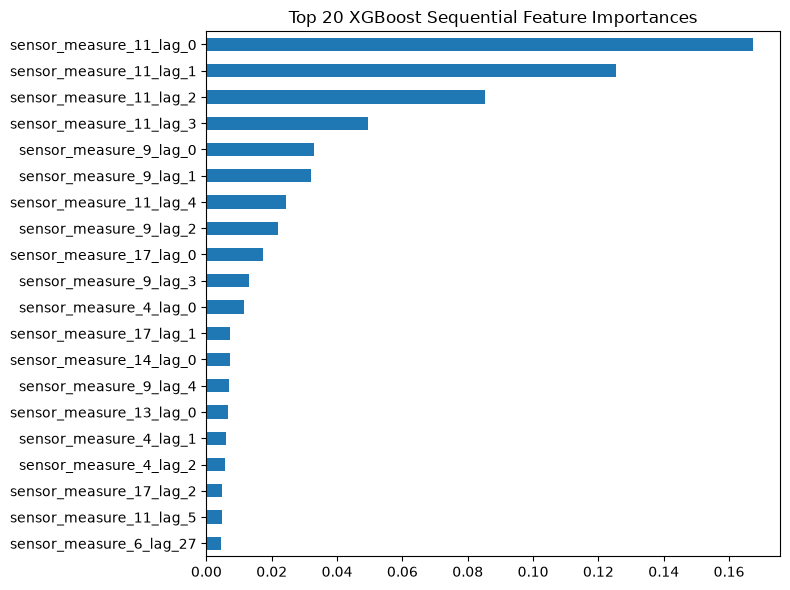

In [17]:
# Dynamically generate names for the flattened sequential features
# Lag 29 is the oldest cycle in the window, Lag 0 is the most recent
seq_feature_cols = [f'{col}_lag_{SEQ_LEN - i - 1}' for i in range(SEQ_LEN) for col in feature_cols]

importances = pd.Series(xgb_model.feature_importances_, index=seq_feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(20).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top 20 XGBoost Sequential Feature Importances')
plt.tight_layout()
plt.show()

## DL

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
EPOCHS = 50
PATIENCE = 15

class RULSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.as_tensor(sequences, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

### LSTM

In [19]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

lstm_train_idx, lstm_val_idx = next(
    splitter.split(train, train['RUL'], groups=train['unit_number'])
)

lstm_train = train.iloc[lstm_train_idx].copy()
lstm_val = train.iloc[lstm_val_idx].copy()

feature_scaler = MinMaxScaler()
feature_scaler.fit(lstm_train[feature_cols])

lstm_train_scaled = lstm_train.copy()
lstm_val_scaled = lstm_val.copy()
test_scaled = test.copy()

lstm_train_scaled[feature_cols] = feature_scaler.transform(lstm_train[feature_cols])
lstm_val_scaled[feature_cols] = feature_scaler.transform(lstm_val[feature_cols])
test_scaled[feature_cols] = feature_scaler.transform(test[feature_cols])


x_train_seq, y_train, train_groups = make_windows(lstm_train_scaled)
x_val_seq, y_valid, val_groups = make_windows(lstm_val_scaled)
x_test_seq, y_test, test_groups = make_windows(test_scaled, last_only=True)

print(f'Train windows: {x_train_seq.shape}, Validation windows: {x_val_seq.shape}, Test windows: {x_test_seq.shape}')


Train windows: (17692, 30, 18), Validation windows: (4128, 30, 18), Test windows: (100, 30, 18)


In [20]:
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_valid.reshape(-1, 1)).flatten()

print(f'Label scaling: min={target_scaler.data_min_[0]:.3f}, max={target_scaler.data_max_[0]:.3f}')


Label scaling: min=0.000, max=125.000


In [21]:
BATCH_SIZE = 128

train_ds = RULSequenceDataset(x_train_seq, y_train_scaled)
val_ds = RULSequenceDataset(x_val_seq, y_val_scaled)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

def build_sequences(df, feature_cols, seq_len=SEQ_LEN, label_col='RUL'):
    sequences, labels, unit_ids = [], [], []

    for unit_id, group in df.groupby('unit_number'):
        group = group.sort_values('time_cycles')
        data = group[feature_cols].values
        target = group[label_col].values

        if len(data) < seq_len:
            continue

        for start in range(len(data) - seq_len + 1):
            end = start + seq_len
            sequences.append(data[start:end])
            labels.append(target[end - 1])
            unit_ids.append(unit_id)

    return np.array(sequences), np.array(labels), np.array(unit_ids)


class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=96, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            n_features,
            hidden_size,
            batch_first=True,
            num_layers=2,
            dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        sequence, _ = self.lstm(x)
        return self.head(sequence[:, -1]) 


In [22]:
lstm_model = LSTMRegressor(n_features=len(feature_cols)).to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.SmoothL1Loss()

In [23]:
def asymmetric_smooth_l1_loss(predictions, targets, overprediction_weight=2.0):
    errors = predictions - targets
    weights = torch.where(errors > 0, overprediction_weight, 1.0)
    return (
        weights
        * nn.functional.smooth_l1_loss(predictions.squeeze(), targets.squeeze(), reduction='none')
    ).mean()


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = asymmetric_smooth_l1_loss(preds, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


In [24]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state = None
patience_counter = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,     
    patience=5,     
)

for epoch in range(EPOCHS):
    train_loss = run_epoch(lstm_model, train_loader, criterion, optimizer)
    val_loss = run_epoch(lstm_model, val_loader, criterion)
    scheduler.step(val_loss) 

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch + 1}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}, lr={current_lr:.6f}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch + 1}')
        break

lstm_model.load_state_dict(best_state)


Epoch 1: train_loss=0.03223, val_loss=0.02228, lr=0.000500
Epoch 2: train_loss=0.01759, val_loss=0.01805, lr=0.000500
Epoch 3: train_loss=0.01568, val_loss=0.01449, lr=0.000500
Epoch 4: train_loss=0.01490, val_loss=0.01452, lr=0.000500
Epoch 5: train_loss=0.01358, val_loss=0.01108, lr=0.000500
Epoch 6: train_loss=0.01183, val_loss=0.01050, lr=0.000500
Epoch 7: train_loss=0.00957, val_loss=0.00965, lr=0.000500
Epoch 8: train_loss=0.00890, val_loss=0.01338, lr=0.000500
Epoch 9: train_loss=0.00831, val_loss=0.01142, lr=0.000500
Epoch 10: train_loss=0.00791, val_loss=0.00876, lr=0.000500
Epoch 11: train_loss=0.00747, val_loss=0.00724, lr=0.000500
Epoch 12: train_loss=0.00749, val_loss=0.00714, lr=0.000500
Epoch 13: train_loss=0.00729, val_loss=0.00726, lr=0.000500
Epoch 14: train_loss=0.00708, val_loss=0.00763, lr=0.000500
Epoch 15: train_loss=0.00695, val_loss=0.00753, lr=0.000500
Epoch 16: train_loss=0.00705, val_loss=0.00863, lr=0.000500
Epoch 17: train_loss=0.00661, val_loss=0.00877, l

<All keys matched successfully>

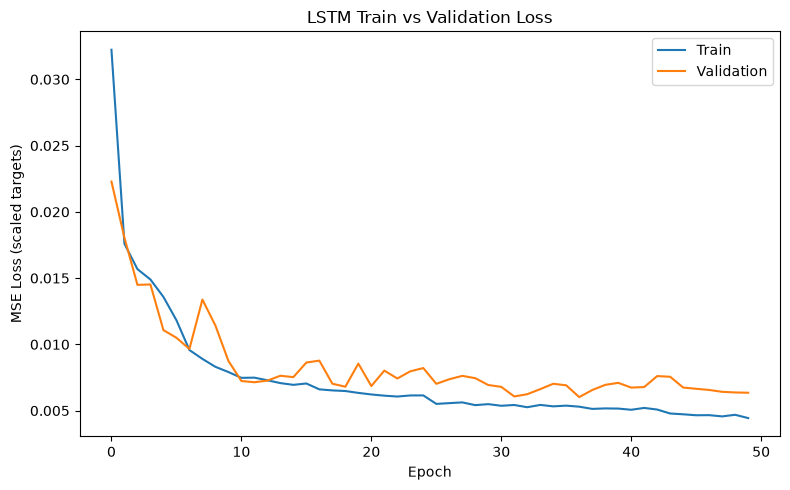

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (scaled targets)')
ax.set_title('LSTM Train vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
test_last_cycle = test.loc[test.groupby('unit_number')['time_cycles'].idxmax()]

x_test_seq, y_test, test_groups = make_windows(test_scaled, last_only=True)
y_test_true = test_last_cycle.set_index('unit_number').loc[test_groups, 'RUL'].values

lstm_model.eval()
with torch.no_grad():
    X_test_tensor = torch.as_tensor(x_test_seq, dtype=torch.float32).to(device)
    lstm_pred_scaled = lstm_model(X_test_tensor).cpu().numpy()

lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

lstm_test_metrics = regression_metrics(y_test_true, lstm_pred)
lstm_test_metrics


{'cmapss_score': 284.7704300931022,
 'mae': 8.680383682250977,
 'rmse': 12.51034667000523,
 'r2': 0.8979722261428833}

### Enhanced LSTM 

In [27]:
class TemporalAttention(nn.Module):
    """Isolated, reusable Attention Module for the BiLSTM"""
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, lstm_out):
        # Calculate attention weights for each time step
        attn_scores = self.attention(lstm_out) 
        attn_weights = torch.softmax(attn_scores, dim=1) 
        
        # Multiply LSTM outputs by attention weights and sum across sequence length
        context_vector = torch.sum(attn_weights * lstm_out, dim=1) 
        return context_vector


class AttentionBiLSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=96, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            n_features,
            hidden_size,
            batch_first=True,
            num_layers=2,
            dropout=dropout,
            bidirectional=True
        )
        
        # Structurally separated attention
        self.temporal_attention = TemporalAttention(hidden_size)
        
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x) 
        context_vector = self.temporal_attention(lstm_out)
        return self.head(context_vector)

In [28]:
lstm_model = AttentionBiLSTMRegressor(n_features=len(feature_cols)).to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.SmoothL1Loss()

In [29]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state = None
patience_counter = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,     
    patience=5,     
)

for epoch in range(EPOCHS):
    train_loss = run_epoch(lstm_model, train_loader, criterion, optimizer)
    val_loss = run_epoch(lstm_model, val_loader, criterion)
    scheduler.step(val_loss) 

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch + 1}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}, lr={current_lr:.6f}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch + 1}')
        break

lstm_model.load_state_dict(best_state)


Epoch 1: train_loss=0.03577, val_loss=0.02278, lr=0.000500
Epoch 2: train_loss=0.02540, val_loss=0.01434, lr=0.000500
Epoch 3: train_loss=0.02300, val_loss=0.01239, lr=0.000500
Epoch 4: train_loss=0.02104, val_loss=0.01118, lr=0.000500
Epoch 5: train_loss=0.01918, val_loss=0.00950, lr=0.000500
Epoch 6: train_loss=0.01728, val_loss=0.00819, lr=0.000500
Epoch 7: train_loss=0.01566, val_loss=0.00841, lr=0.000500
Epoch 8: train_loss=0.01501, val_loss=0.00877, lr=0.000500
Epoch 9: train_loss=0.01403, val_loss=0.00825, lr=0.000500
Epoch 10: train_loss=0.01344, val_loss=0.00869, lr=0.000500
Epoch 11: train_loss=0.01291, val_loss=0.00821, lr=0.000500
Epoch 12: train_loss=0.01249, val_loss=0.00717, lr=0.000500
Epoch 13: train_loss=0.01210, val_loss=0.00799, lr=0.000500
Epoch 14: train_loss=0.01154, val_loss=0.00878, lr=0.000500
Epoch 15: train_loss=0.01116, val_loss=0.00703, lr=0.000500
Epoch 16: train_loss=0.01102, val_loss=0.00718, lr=0.000500
Epoch 17: train_loss=0.01066, val_loss=0.00780, l

<All keys matched successfully>

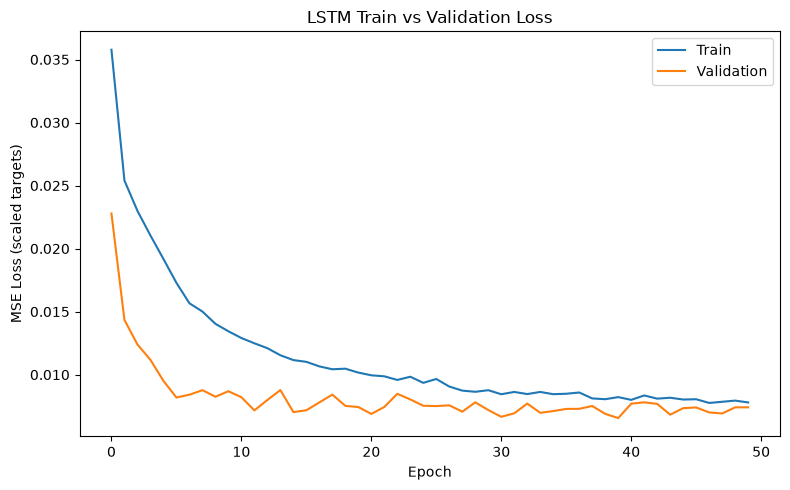

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (scaled targets)')
ax.set_title('LSTM Train vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
test_last_cycle = test.loc[test.groupby('unit_number')['time_cycles'].idxmax()]

x_test_seq, y_test, test_groups = make_windows(test_scaled, last_only=True)
y_test_true = test_last_cycle.set_index('unit_number').loc[test_groups, 'RUL'].values

lstm_model.eval()
with torch.no_grad():
    X_test_tensor = torch.as_tensor(x_test_seq, dtype=torch.float32).to(device)
    lstm_pred_scaled = lstm_model(X_test_tensor).cpu().numpy()

lstm_pred = target_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

lstm_test_metrics_2 = regression_metrics(y_test_true, lstm_pred)
lstm_test_metrics_2

{'cmapss_score': 386.9920310689875,
 'mae': 8.791984558105469,
 'rmse': 12.790026498488237,
 'r2': 0.8933594226837158}

### Autoformer

In [32]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

autoformer_train_idx, autoformer_val_idx = next(
    splitter.split(train, train['RUL'], groups=train['unit_number'])
)

autoformer_train = train.iloc[autoformer_train_idx].copy()
autoformer_val = train.iloc[autoformer_val_idx].copy()

# 2. Strict feature scaler fitting on training subset only
feature_scaler = MinMaxScaler()
feature_scaler.fit(autoformer_train[feature_cols])

autoformer_train_scaled = autoformer_train.copy()
autoformer_val_scaled = autoformer_val.copy()
test_scaled = test.copy()

autoformer_train_scaled[feature_cols] = feature_scaler.transform(autoformer_train[feature_cols])
autoformer_val_scaled[feature_cols] = feature_scaler.transform(autoformer_val[feature_cols])
test_scaled[feature_cols] = feature_scaler.transform(test[feature_cols])

x_train_seq, y_train, train_groups = make_windows(autoformer_train_scaled, seq_len=SEQ_LEN)
x_val_seq, y_valid, val_groups = make_windows(autoformer_val_scaled, seq_len=SEQ_LEN)
x_test_seq, y_test, test_groups = make_windows(test_scaled, seq_len=SEQ_LEN, last_only=True)

In [33]:
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_valid.reshape(-1, 1)).flatten()

In [34]:
BATCH_SIZE = 128
train_ds = RULSequenceDataset(x_train_seq, y_train_scaled)
val_ds = RULSequenceDataset(x_val_seq, y_val_scaled)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Autoformer Train Windows: {x_train_seq.shape}, Val Windows: {x_val_seq.shape}, Test Windows: {x_test_seq.shape}")

Autoformer Train Windows: (17692, 30, 18), Val Windows: (4128, 30, 18), Test Windows: (100, 30, 18)


In [35]:
class SeriesDecomposition(nn.Module):
    """
    Extracts the trend-cyclical and seasonal-oscillatory components
    of the input time series using 1D average pooling.
    """
    def __init__(self, kernel_size=5):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        num_of_pads = (self.kernel_size - 1) // 2
        front = x[:, 0:1, :].repeat(1, num_of_pads, 1)
        end = x[:, -1:, :].repeat(1, num_of_pads, 1)
        x_padded = torch.cat([front, x, end], dim=1)
        
        # Trend component via moving average
        x_trend = self.avg(x_padded.permute(0, 2, 1)).permute(0, 2, 1)
        x_seasonal = x - x_trend
        return x_seasonal, x_trend


class AutoCorrelation(nn.Module):
    """
    Frequency-domain auto-correlation mechanism via FFT with Time-Delay Aggregation.
    Replaces standard QK^T dot-product self-attention with period-based dependencies.
    """
    def __init__(self, d_model, num_heads=4, autocorrelation_factor=2, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.autocorrelation_factor = autocorrelation_factor
        self.dropout = nn.Dropout(dropout)
        
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def time_delay_aggregation(self, values, corr):
        # values: [batch_size, num_heads, seq_len, head_dim]
        # corr:   [batch_size, num_heads, seq_len]
        batch_size, num_heads, seq_len, head_dim = values.shape
        top_k = int(self.autocorrelation_factor * math.log(seq_len))
        top_k = max(1, min(top_k, seq_len))
        
        # Find top-k autocorrelation values and corresponding lag indices
        weights, delays = torch.topk(corr, top_k, dim=-1)
        weights = F.softmax(weights, dim=-1)
        
        aggregated_values = torch.zeros_like(values)
        for i in range(top_k):
            # Roll values according to phase-lag delay
            delay_indices = delays[:, :, i]  # [batch_size, num_heads]
            avg_delay = int(torch.round(delay_indices.float().mean()).item())
            rolled_values = torch.roll(values, shifts=-avg_delay, dims=2)
            
            w = weights[:, :, i].unsqueeze(-1).unsqueeze(-1)
            aggregated_values += rolled_values * w
            
        return aggregated_values

    def forward(self, q, k, v):
        batch_size, seq_len, _ = q.shape
        
        # Project and reshape to multi-head: [batch_size, num_heads, seq_len, head_dim]
        Q = self.q_proj(q).view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        K = self.k_proj(k).view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        V = self.v_proj(v).view(batch_size, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        
        # Cross-correlation computed via Wiener-Khinchin theorem (RFFT -> conj-mult -> IRFFT)
        Q_fft = torch.fft.rfft(Q, dim=2)
        K_fft = torch.fft.rfft(K, dim=2)
        corr_fft = Q_fft * torch.conj(K_fft)
        corr = torch.fft.irfft(corr_fft, n=seq_len, dim=2)  # [batch_size, num_heads, seq_len, head_dim]
        
        # Mean across head dimensions to obtain scalar lag weights
        corr_mean = torch.mean(corr, dim=-1)  # [batch_size, num_heads, seq_len]
        
        # Aggregate representations across primary time delays
        aggregated_v = self.time_delay_aggregation(V, corr_mean)
        
        # Permute and project back to d_model
        out = aggregated_v.permute(0, 2, 1, 3).contiguous().view(batch_size, seq_len, self.d_model)
        return self.dropout(self.out_proj(out))


class AutoformerEncoderLayer(nn.Module):
    """
    Encoder block with progressive series decomposition and feedforward sublayers.
    """
    def __init__(self, d_model, num_heads=4, d_ff=128, kernel_size=5, dropout=0.1):
        super().__init__()
        self.decomp1 = SeriesDecomposition(kernel_size)
        self.decomp2 = SeriesDecomposition(kernel_size)
        self.autocorrelation = AutoCorrelation(d_model, num_heads=num_heads, dropout=dropout)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Auto-correlation on seasonal residual with decomposition
        seasonal, _ = self.decomp1(x)
        attn_out = self.autocorrelation(seasonal, seasonal, seasonal)
        x = self.norm1(x + attn_out)
        
        # Feedforward network with decomposition
        seasonal, _ = self.decomp2(x)
        ffn_out = self.ffn(seasonal)
        x = self.norm2(x + ffn_out)
        return x


class AutoformerRegressor(nn.Module):
    """
    Complete Autoformer architecture adapted for C-MAPSS RUL Sequence Regression.
    """
    def __init__(self, n_features, d_model=64, num_heads=4, d_ff=128, num_layers=2, kernel_size=5, dropout=0.2):
        super().__init__()
        # Linear feature tokenizer
        self.input_embedding = nn.Linear(n_features, d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Stacked Autoformer encoder layers
        self.encoder_layers = nn.ModuleList([
            AutoformerEncoderLayer(
                d_model=d_model,
                num_heads=num_heads,
                d_ff=d_ff,
                kernel_size=kernel_size,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])
        
        self.decomp = SeriesDecomposition(kernel_size)
        
        # Regression prediction head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: [batch_size, seq_len, n_features]
        out = self.dropout(self.input_embedding(x))
        
        for layer in self.encoder_layers:
            out = layer(out)
            
        seasonal, trend = self.decomp(out)
        latent = seasonal[:, -1, :] + trend[:, -1, :]
        
        return self.head(latent)

In [36]:
autoformer_model = AutoformerRegressor(
    n_features=len(feature_cols),
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_layers=2,
    kernel_size=5,
    dropout=0.2
).to(device)

optimizer = torch.optim.AdamW(autoformer_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.SmoothL1Loss()

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state = None
patience_counter = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

for epoch in range(EPOCHS):
    train_loss = run_epoch(autoformer_model, train_loader, criterion, optimizer)
    val_loss = run_epoch(autoformer_model, val_loader, criterion)
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in autoformer_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch + 1:02d}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}, lr={current_lr:.6f}")
    
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

# Restore best weights
autoformer_model.load_state_dict(best_state)

Epoch 01: train_loss=0.06362, val_loss=0.02475, lr=0.001000
Epoch 02: train_loss=0.02485, val_loss=0.01677, lr=0.001000
Epoch 03: train_loss=0.02265, val_loss=0.01697, lr=0.001000
Epoch 04: train_loss=0.02067, val_loss=0.02262, lr=0.001000
Epoch 05: train_loss=0.01974, val_loss=0.01459, lr=0.001000
Epoch 06: train_loss=0.01885, val_loss=0.01517, lr=0.001000
Epoch 07: train_loss=0.01849, val_loss=0.01335, lr=0.001000
Epoch 08: train_loss=0.01814, val_loss=0.01386, lr=0.001000
Epoch 09: train_loss=0.01772, val_loss=0.01302, lr=0.001000
Epoch 10: train_loss=0.01718, val_loss=0.01214, lr=0.001000
Epoch 11: train_loss=0.01679, val_loss=0.01522, lr=0.001000
Epoch 12: train_loss=0.01643, val_loss=0.01270, lr=0.001000
Epoch 13: train_loss=0.01628, val_loss=0.01521, lr=0.001000
Epoch 14: train_loss=0.01597, val_loss=0.01322, lr=0.001000
Epoch 15: train_loss=0.01580, val_loss=0.01450, lr=0.001000
Epoch 16: train_loss=0.01558, val_loss=0.01467, lr=0.000500
Epoch 17: train_loss=0.01522, val_loss=0

<All keys matched successfully>

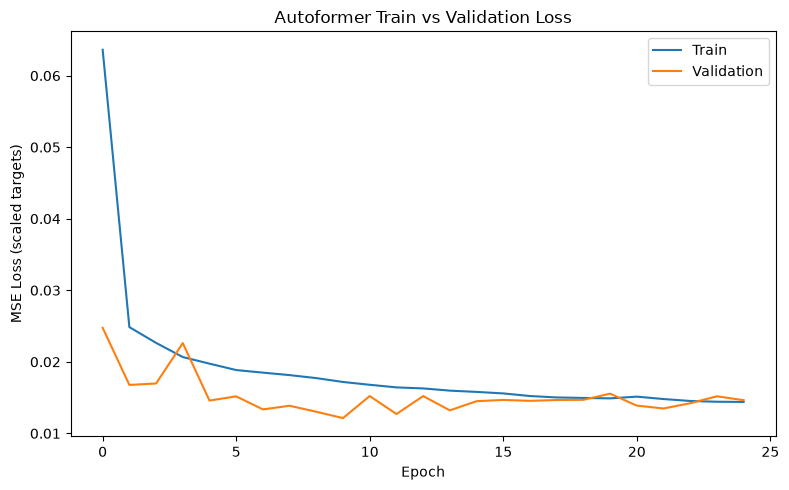

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (scaled targets)')
ax.set_title('Autoformer Train vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
test_last_cycle = test.loc[test.groupby('unit_number')['time_cycles'].idxmax()]
x_test_seq, y_test, test_groups = make_windows(test_scaled, seq_len=SEQ_LEN, last_only=True)
y_test_true = test_last_cycle.set_index('unit_number').loc[test_groups, 'RUL'].values

autoformer_model.eval()
with torch.no_grad():
    X_test_tensor = torch.as_tensor(x_test_seq, dtype=torch.float32).to(device)
    autoformer_pred_scaled = autoformer_model(X_test_tensor).cpu().numpy()

autoformer_pred = target_scaler.inverse_transform(autoformer_pred_scaled.reshape(-1, 1)).flatten()

autoformer_test_metrics = regression_metrics(y_test_true, autoformer_pred)
autoformer_test_metrics

{'cmapss_score': 1269.4241212254747,
 'mae': 13.328364372253418,
 'rmse': 18.070174015898235,
 'r2': 0.7871350049972534}

### Enhanced Autoformer

In [39]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.trunc_normal_(self.pe, std=0.02)

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]


class DataEmbedding(nn.Module):
    """Isolated Tokenizer Module"""
    def __init__(self, n_features, d_model, dropout=0.1):
        super().__init__()
        self.conv_in = nn.Sequential(
            nn.Conv1d(n_features, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU()
        )
        self.pos_emb = PositionalEncoding(d_model, max_len=100)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x_conv = self.conv_in(x.permute(0, 2, 1)).permute(0, 2, 1)
        return self.dropout(self.pos_emb(x_conv))


class AutoformerRegressorV2(nn.Module):
    def __init__(self, n_features, d_model=64, num_heads=4, d_ff=128, num_layers=2, kernel_size=3, dropout=0.2, head_dropout=0.4):
        super().__init__()
        self.embedding = DataEmbedding(n_features, d_model, dropout)
        
        self.encoder_layers = nn.ModuleList([
            AutoformerEncoderLayer(
                d_model=d_model, num_heads=num_heads, d_ff=d_ff, 
                kernel_size=kernel_size, dropout=dropout
            )
            for _ in range(num_layers)
        ])
        
        self.decomp = SeriesDecomposition(kernel_size)
        self.norm_combined = nn.LayerNorm(d_model)
        
        self.head = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, 64),
            nn.GELU(),
            nn.Dropout(head_dropout), 
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out = self.embedding(x)
        
        for layer in self.encoder_layers:
            out = layer(out)
            
        seasonal, trend = self.decomp(out)
        combined_seq = self.norm_combined(seasonal + trend) 
        
        global_pool = torch.mean(combined_seq, dim=1)
        last_step = combined_seq[:, -1, :]
        fused_latent = torch.cat([global_pool, last_step], dim=-1) 
        
        return self.head(fused_latent)


In [40]:
autoformer_model_v2 = AutoformerRegressorV2(
    n_features=len(feature_cols),
    d_model=64, num_heads=4, d_ff=128, num_layers=2, kernel_size=3, dropout=0.15
).to(device)

# Asymmetric penalty to strictly penalize over-prediction matching C-MAPSS logic
def balanced_smooth_l1_loss(predictions, targets, overprediction_weight=2.5):
    errors = predictions - targets
    weights = torch.where(errors > 0, overprediction_weight, 1.0)
    return (
        weights * nn.functional.smooth_l1_loss(predictions.squeeze(), targets.squeeze(), reduction='none')
    ).mean()

optimizer = torch.optim.AdamW(autoformer_model_v2.parameters(), lr=7e-4, weight_decay=1e-4)

def run_epoch_v2(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = balanced_smooth_l1_loss(preds, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [41]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state = None
patience_counter = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

for epoch in range(EPOCHS):
    train_loss = run_epoch_v2(autoformer_model_v2, train_loader, criterion, optimizer)
    val_loss = run_epoch_v2(autoformer_model_v2, val_loader, criterion)
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in autoformer_model_v2.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch + 1:02d}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}, lr={current_lr:.6f}")
    
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

autoformer_model_v2.load_state_dict(best_state)

Epoch 01: train_loss=0.05231, val_loss=0.01875, lr=0.000700
Epoch 02: train_loss=0.02754, val_loss=0.01734, lr=0.000700
Epoch 03: train_loss=0.02456, val_loss=0.01545, lr=0.000700
Epoch 04: train_loss=0.02329, val_loss=0.01727, lr=0.000700
Epoch 05: train_loss=0.02202, val_loss=0.01474, lr=0.000700
Epoch 06: train_loss=0.01962, val_loss=0.01923, lr=0.000700
Epoch 07: train_loss=0.01761, val_loss=0.01422, lr=0.000700
Epoch 08: train_loss=0.01671, val_loss=0.01469, lr=0.000700
Epoch 09: train_loss=0.01513, val_loss=0.01415, lr=0.000700
Epoch 10: train_loss=0.01386, val_loss=0.01502, lr=0.000700
Epoch 11: train_loss=0.01319, val_loss=0.03055, lr=0.000700
Epoch 12: train_loss=0.01143, val_loss=0.01958, lr=0.000700
Epoch 13: train_loss=0.01057, val_loss=0.01643, lr=0.000700
Epoch 14: train_loss=0.01047, val_loss=0.03193, lr=0.000700
Epoch 15: train_loss=0.00971, val_loss=0.01938, lr=0.000350
Epoch 16: train_loss=0.00882, val_loss=0.01792, lr=0.000350
Epoch 17: train_loss=0.00844, val_loss=0

<All keys matched successfully>

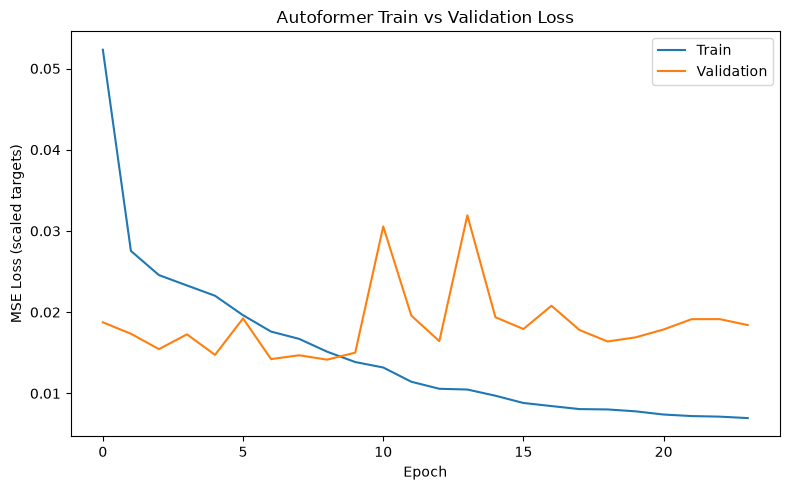

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (scaled targets)')
ax.set_title('Autoformer Train vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
test_last_cycle = test.loc[test.groupby('unit_number')['time_cycles'].idxmax()]
x_test_seq, y_test, test_groups = make_windows(test_scaled, seq_len=SEQ_LEN, last_only=True)
y_test_true = test_last_cycle.set_index('unit_number').loc[test_groups, 'RUL'].values

autoformer_model_v2.eval()
with torch.no_grad():
    X_test_tensor = torch.as_tensor(x_test_seq, dtype=torch.float32).to(device)
    autoformer_pred_scaled = autoformer_model_v2(X_test_tensor).cpu().numpy()

autoformer_pred = target_scaler.inverse_transform(autoformer_pred_scaled.reshape(-1, 1)).flatten()

autoformer_test_metrics_2 = regression_metrics(y_test_true, autoformer_pred)
autoformer_test_metrics_2

{'cmapss_score': 884.3706495348612,
 'mae': 13.858680725097656,
 'rmse': 17.960776933547184,
 'r2': 0.7897045612335205}

## Final Model Comparison and Candidate Selection


To conclude our modeling pipeline, we need to evaluate the three architectures—**XGBoost**, **LSTM**, and the **Optimized Autoformer**—side-by-side. 

In predictive maintenance, particularly with the C-MAPSS dataset, raw accuracy ($R^2$ and RMSE) only tells half the story. The **C-MAPSS Score** introduces an asymmetric penalty: predicting an engine will fail *later* than it actually does (over-prediction) is penalized exponentially more than predicting it will fail *early* (under-prediction), reflecting the catastrophic real-world cost of inflight engine failure. 

The ideal candidate must balance high variance explanation ($R^2$) with low C-MAPSS penalty score.

Final Test Metrics Comparison:


,cmapss_score,mae,rmse,r2
XGBoost,2207.676,15.093,20.798,0.718
XGBoost v2,560.881,10.806,14.680,0.860
LSTM,284.770,8.680,12.510,0.898
LSTM v2,386.992,8.792,12.790,0.893
Autoformer,1269.424,13.328,18.070,0.787
Autoformer v2,884.371,13.859,17.961,0.790


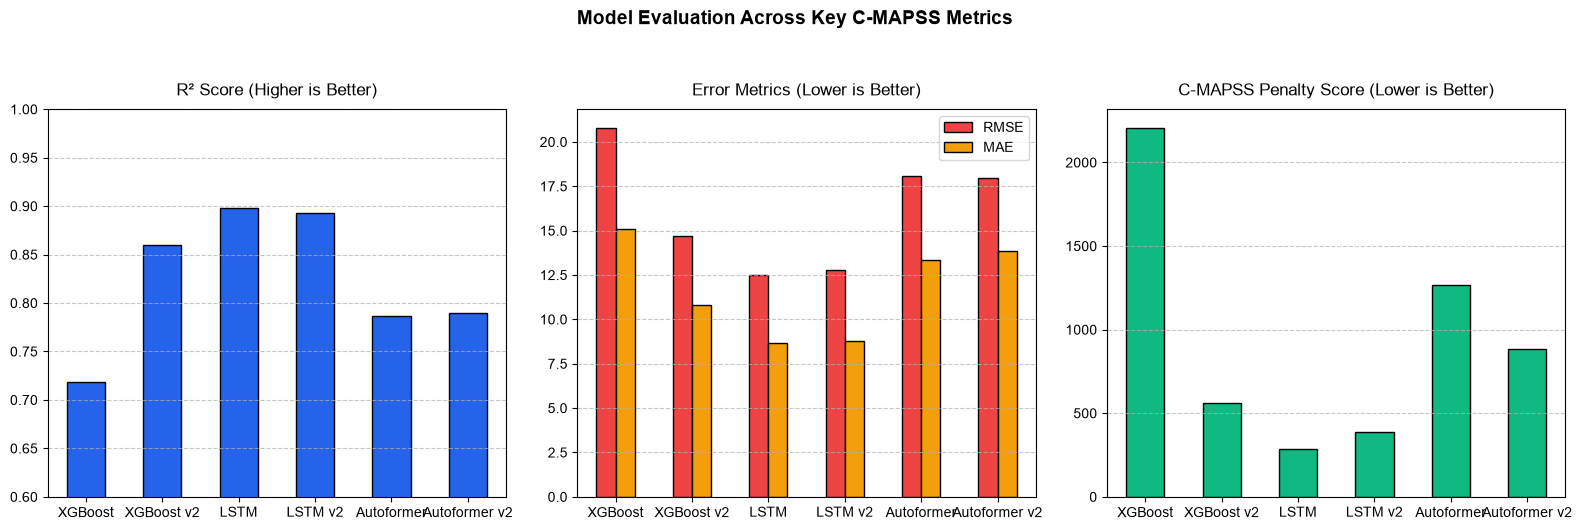

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    'XGBoost': xgb_test_metrics,
    'XGBoost v2': xgb_test_metrics_2,
    'LSTM': lstm_test_metrics,
    'LSTM v2': lstm_test_metrics_2,
    'Autoformer': autoformer_test_metrics,
    'Autoformer v2': autoformer_test_metrics_2,
}).T

print("Final Test Metrics Comparison:")
display(metrics_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plt.rcParams.update({'font.sans-serif': ['Segoe UI', 'Arial']})

metrics_df[['r2']].plot(kind='bar', ax=axes[0], color=['#2563EB'], edgecolor='black', legend=False)
axes[0].set_title('R² Score (Higher is Better)', pad=10)
axes[0].set_ylim(0.6, 1.0)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

metrics_df[['rmse', 'mae']].plot(kind='bar', ax=axes[1], color=['#EF4444', '#F59E0B'], edgecolor='black')
axes[1].set_title('Error Metrics (Lower is Better)', pad=10)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(['RMSE', 'MAE'])

metrics_df[['cmapss_score']].plot(kind='bar', ax=axes[2], color=['#10B981'], edgecolor='black', legend=False)
axes[2].set_title('C-MAPSS Penalty Score (Lower is Better)', pad=10)
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Model Evaluation Across Key C-MAPSS Metrics', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_cmapss_model = metrics_df['cmapss_score'].idxmin()
best_rmse_model = metrics_df['rmse'].idxmin()

In [45]:
print("FINAL CANDIDATE: ", best_cmapss_model,
      f"\nAchieved the lowest RMSE {metrics_df.loc[best_cmapss_model, 'rmse']:.2f} and {metrics_df.loc[best_cmapss_model, 'cmapss_score']:.1f} C-MAPSS score.")

FINAL CANDIDATE:  LSTM 
Achieved the lowest RMSE 12.51 and 284.8 C-MAPSS score.
